## Pré-processing général

In [1]:
import pandas as pd
import numpy as np
import re
import spacy
from sklearn.preprocessing import normalize
!pip install fasttext
import fasttext
from tqdm import tqdm
import pickle

In [3]:
import psutil

print("=== CPU ===")
cpu_physical = psutil.cpu_count(logical=False)
cpu_logical = psutil.cpu_count(logical=True)
cpu_freq = psutil.cpu_freq().max
print(f"Cœurs physiques : {cpu_physical}")
print(f"Cœurs logiques : {cpu_logical}")
print(f"Fréquence max : {cpu_freq:.2f} MHz")

print("\n=== RAM ===")
ram = psutil.virtual_memory()
print(f"RAM totale : {ram.total / (1024**3):.2f} GB")
print(f"RAM disponible : {ram.available / (1024**3):.2f} GB")

print("\n=== GPU ===")
try:
    import torch
    if torch.cuda.is_available():
        num_gpus = torch.cuda.device_count()
        print(f"Nombre de GPU : {num_gpus}")
        for i in range(num_gpus):
            name = torch.cuda.get_device_name(i)
            total_mem = torch.cuda.get_device_properties(i).total_memory / 1e9
            print(f"GPU {i} : {name} | Mem totale : {total_mem:.2f} GB")
    else:
        print("Aucun GPU disponible")
except ImportError:
    print("Torch non installé, impossible de vérifier le GPU")

=== CPU ===
Cœurs physiques : 8
Cœurs logiques : 16
Fréquence max : 0.00 MHz

=== RAM ===
RAM totale : 15.27 GB
RAM disponible : 9.82 GB

=== GPU ===
Nombre de GPU : 1
GPU 0 : NVIDIA GeForce RTX 4070 Laptop GPU | Mem totale : 8.59 GB


In [4]:
df = pd.read_csv('../data/raw/reviews_trust.csv')
df

,Commentaire,star,date,client,reponse,source,company,ville,maj,date_commande,ecart
0,"Bonjour , Ca doit faire 5 ans environ que je s...",1,2021-06-20 00:00:00+00:00,AUDREY Du 62,NaN,TrustPilot,ShowRoom,NaN,NaN,NaN,NaN
1,Vente lacoste article manquant photo prise sur...,1,2021-06-20 00:00:00+00:00,Nanasky De Verteuil,NaN,TrustPilot,ShowRoom,NaN,NaN,NaN,NaN
2,"Vente Lacoste Honteuse , article erroné , arti...",1,2021-06-19 00:00:00+00:00,Vanessa L,NaN,TrustPilot,ShowRoom,NaN,NaN,NaN,NaN
3,J'ai commandé des mules de la marque Moosefiel...,2,2021-06-19 00:00:00+00:00,Valery PERRAULT,"Bonjour , Je suis sincèrement navré d'apprendr...",TrustPilot,ShowRoom,NaN,NaN,NaN,NaN
4,Commande téléphone etat A+ . Livraison d un vi...,1,2021-06-19 00:00:00+00:00,JULIE DRINGENBERG,"Bonjour Julie , Je suis sincèrement désolé de ...",TrustPilot,ShowRoom,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
19858,Pas de probleme,4,2015-10-07 00:00:00+00:00,Dark dav,NaN,TrustPilot,VeePee,NaN,NaN,NaN,NaN
19859,Cliente depuis 2008 sans encombre jusqu ' à ju...,1,2015-10-06 00:00:00+00:00,Bertho,NaN,TrustPilot,VeePee,NaN,NaN,NaN,NaN
19860,Je ne sais pas si VP cherche à vendre ou à fai...,1,2015-10-21 00:00:00+00:00,Anne laure,NaN,TrustPilot,VeePee,NaN,NaN,NaN,NaN
19861,Je suis client sur ce site depuis plusieurs an...,5,2015-10-02 00:00:00+00:00,Thomas GUILLAUME,NaN,TrustPilot,VeePee,NaN,NaN,NaN,NaN


In [5]:
# Suppression des doublons et des commentaires vides ou trop courts
df = df.dropna(subset=["Commentaire"])
df = df.drop_duplicates(subset=['Commentaire', 'client'], keep='first')

def count_words(text):
    text = re.sub(r'[^\w\s]', '', text)
    return len(text.split())
df = df[df['Commentaire'].apply(count_words) > 3]

# df = df[df['Commentaire'].apply(lambda x: len(x.split())) >= 3]
df.shape

(15859, 11)

In [6]:
# Nettoyage du texte avant la vectorisation
def clean_text(text):
    text = text.lower().strip()

    # Suppression des éléments inutiles à l'aide de regex
    text = re.sub(r"(http|www)\S+", "", text) # URLs
    text = re.sub(r"\S+@\S+", "", text) # emails
    text = re.sub(r"(@|#)\w+", "", text) # mentions @ et #
    text = re.sub(r"\s+", " ", text).strip() # espaces multiples, sauts de lignes, tabulations
    return text

df["clean_comment"] = df["Commentaire"].apply(clean_text)

In [7]:
# Suppression des commentaires pas en français
# langue 1 = fr -> c'est bien du français
# langue 1 != fr et langue 2 = fr -> si langue 2 > 0.15 et langue 1 < 0.86 -> français

model = fasttext.load_model('../models/language_detection/lid.176.ftz')
texts = df["clean_comment"].tolist()

labels, probs = model.predict(texts, k=2)

mask = []
for lbls, pbs in zip(labels, probs):
    lang1 = lbls[0] if len(lbls) > 0 else None
    lang2 = lbls[1] if len(lbls) > 1 else None
    prob1 = pbs[0] if len(pbs) > 0 else 0.0
    prob2 = pbs[1] if len(pbs) > 1 else 0.0

    # Cas 1 : langue 1 = français
    if lang1 == "__label__fr":
        mask.append(True)
    # Cas 2 : langue 2 = français avec seuils
    elif lang2 == "__label__fr" and prob1 < 0.86 and prob2 > 0.15:
        mask.append(True)
    else:
        mask.append(False)

df = df[mask].reset_index(drop=True)

In [8]:
df.shape

(15077, 12)

In [9]:
# Pour regarder les seuils correspondant à chaque langue

# labels, probs = model.predict(texts, k=3)

# def get_label(lbls, probs, idx):
#     if idx < len(lbls):
#         return lbls[idx].replace("__label__", ""), float(probs[idx])
#     else:
#         return None, 0.0

# lang_1, prob_1 = zip(*[get_label(lbls, pb, 0) for lbls, pb in zip(labels, probs)])
# lang_2, prob_2 = zip(*[get_label(lbls, pb, 1) for lbls, pb in zip(labels, probs)])
# lang_3, prob_3 = zip(*[get_label(lbls, pb, 2) for lbls, pb in zip(labels, probs)])

# df["lang_1"], df["prob_1"] = lang_1, prob_1
# df["lang_2"], df["prob_2"] = lang_2, prob_2
# df["lang_3"], df["prob_3"] = lang_3, prob_3

# df.to_excel("drive/MyDrive/TrustPilot/detect_lang.xlsx", index=False)

In [10]:
!python -m spacy download fr_core_news_md
nlp = spacy.load("fr_core_news_md")

def is_valid_sentence(s):
    return bool(re.search(r"[A-Za-zÀ-ÖØ-öø-ÿ]", s))

def split_into_sentences(doc):
    return [sent.text.strip() 
            for sent in doc.sents 
            if is_valid_sentence(sent.text.strip())]

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.8/45.8 MB 37.8 MB/s eta 0:00:0000:0100:01
✔ Download and installation successful
You can now load the package via spacy.load('fr_core_news_md')


## Segmntation en phrases

In [11]:
docs = list(tqdm(nlp.pipe(df["clean_comment"], batch_size=64, n_process=8), total=len(df))) # à adapter selon les coeurs du CPU et la RAM de la machine

df_sentences = df.copy()
df_sentences["comment_id"] = df.index          # garder index original du commentaire
df_sentences["sentences_list"] = [split_into_sentences(doc) for doc in docs]

df_sentences = df_sentences.explode("sentences_list")

df_sentences = df_sentences.rename(columns={"sentences_list": "sentence"})

df_sentences["sentence"] = df_sentences["sentence"].astype(str).str.strip()
df_sentences = df_sentences[df_sentences["sentence"].apply(count_words) > 3]

df_sentences = df_sentences.reset_index(drop=True)

# Résultat
print(f"Nombre de lignes dans df : {len(df)}")
print(f"Nombre de lignes dans df_sentences : {len(df_sentences)}")

100%|██████████████████████████████████████████| 15077/15077 [00:28<00:00, 532.93it/s]


Nombre de lignes dans df : 15077
Nombre de lignes dans df_sentences : 37628


In [12]:
df_sentences

,Commentaire,star,date,client,reponse,source,company,ville,maj,date_commande,ecart,clean_comment,comment_id,sentence
0,"Bonjour , Ca doit faire 5 ans environ que je s...",1,2021-06-20 00:00:00+00:00,AUDREY Du 62,NaN,TrustPilot,ShowRoom,NaN,NaN,NaN,NaN,"bonjour , ca doit faire 5 ans environ que je s...",0,"bonjour , ca doit faire 5 ans environ que je s..."
1,"Bonjour , Ca doit faire 5 ans environ que je s...",1,2021-06-20 00:00:00+00:00,AUDREY Du 62,NaN,TrustPilot,ShowRoom,NaN,NaN,NaN,NaN,"bonjour , ca doit faire 5 ans environ que je s...",0,je n ’ ai jamais eu de soucis en particulier à...
2,"Bonjour , Ca doit faire 5 ans environ que je s...",1,2021-06-20 00:00:00+00:00,AUDREY Du 62,NaN,TrustPilot,ShowRoom,NaN,NaN,NaN,NaN,"bonjour , ca doit faire 5 ans environ que je s...",0,j ’ ai eu 3 commandes annulées d ’ affiliés… à...
3,"Bonjour , Ca doit faire 5 ans environ que je s...",1,2021-06-20 00:00:00+00:00,AUDREY Du 62,NaN,TrustPilot,ShowRoom,NaN,NaN,NaN,NaN,"bonjour , ca doit faire 5 ans environ que je s...",0,la 1 ère commande « machines et cafés
4,"Bonjour , Ca doit faire 5 ans environ que je s...",1,2021-06-20 00:00:00+00:00,AUDREY Du 62,NaN,TrustPilot,ShowRoom,NaN,NaN,NaN,NaN,"bonjour , ca doit faire 5 ans environ que je s...",0,"» 89,99€… annulé 1 mois après …la 2e commande ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37623,Je suis client sur ce site depuis plusieurs an...,5,2015-10-02 00:00:00+00:00,Thomas GUILLAUME,NaN,TrustPilot,VeePee,NaN,NaN,NaN,NaN,je suis client sur ce site depuis plusieurs an...,15075,les marques sont variés et concernent des prod...
37624,Je suis client sur ce site depuis plusieurs an...,5,2015-10-02 00:00:00+00:00,Thomas GUILLAUME,NaN,TrustPilot,VeePee,NaN,NaN,NaN,NaN,je suis client sur ce site depuis plusieurs an...,15075,les prix sont parfois aléatoires ( de la tres ...
37625,Je suis client sur ce site depuis plusieurs an...,5,2015-10-02 00:00:00+00:00,Thomas GUILLAUME,NaN,TrustPilot,VeePee,NaN,NaN,NaN,NaN,je suis client sur ce site depuis plusieurs an...,15075,certes les délais sont parfois longs
37626,Je suis client sur ce site depuis plusieurs an...,5,2015-10-02 00:00:00+00:00,Thomas GUILLAUME,NaN,TrustPilot,VeePee,NaN,NaN,NaN,NaN,je suis client sur ce site depuis plusieurs an...,15075,mais cela a toujours été le principe des vente...


In [13]:
df_sentences[["Commentaire", "comment_id", "sentence"]]

,Commentaire,comment_id,sentence
0,"Bonjour , Ca doit faire 5 ans environ que je s...",0,"bonjour , ca doit faire 5 ans environ que je s..."
1,"Bonjour , Ca doit faire 5 ans environ que je s...",0,je n ’ ai jamais eu de soucis en particulier à...
2,"Bonjour , Ca doit faire 5 ans environ que je s...",0,j ’ ai eu 3 commandes annulées d ’ affiliés… à...
3,"Bonjour , Ca doit faire 5 ans environ que je s...",0,la 1 ère commande « machines et cafés
4,"Bonjour , Ca doit faire 5 ans environ que je s...",0,"» 89,99€… annulé 1 mois après …la 2e commande ..."
...,...,...,...
37623,Je suis client sur ce site depuis plusieurs an...,15075,les marques sont variés et concernent des prod...
37624,Je suis client sur ce site depuis plusieurs an...,15075,les prix sont parfois aléatoires ( de la tres ...
37625,Je suis client sur ce site depuis plusieurs an...,15075,certes les délais sont parfois longs
37626,Je suis client sur ce site depuis plusieurs an...,15075,mais cela a toujours été le principe des vente...


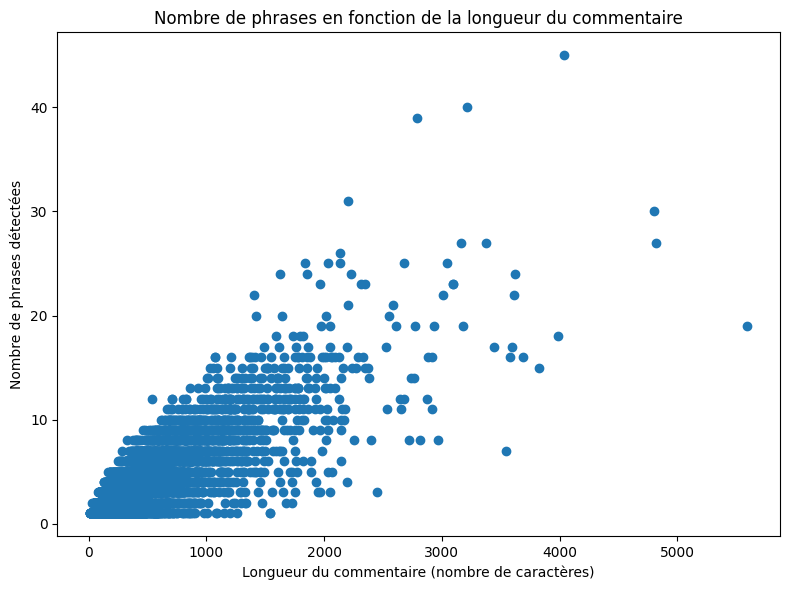

In [15]:
import matplotlib.pyplot as plt

df["comment_length"] = df["clean_comment"].str.len()

sentence_counts = df_sentences.groupby("comment_id").size()

stats = df[["comment_length"]].copy()
stats["n_sentences"] = sentence_counts

plt.figure(figsize=(8, 6))
plt.scatter(stats["comment_length"], stats["n_sentences"])
plt.xlabel("Longueur du commentaire (nombre de caractères)")
plt.ylabel("Nombre de phrases détectées")
plt.title("Nombre de phrases en fonction de la longueur du commentaire")
plt.tight_layout()
plt.show()

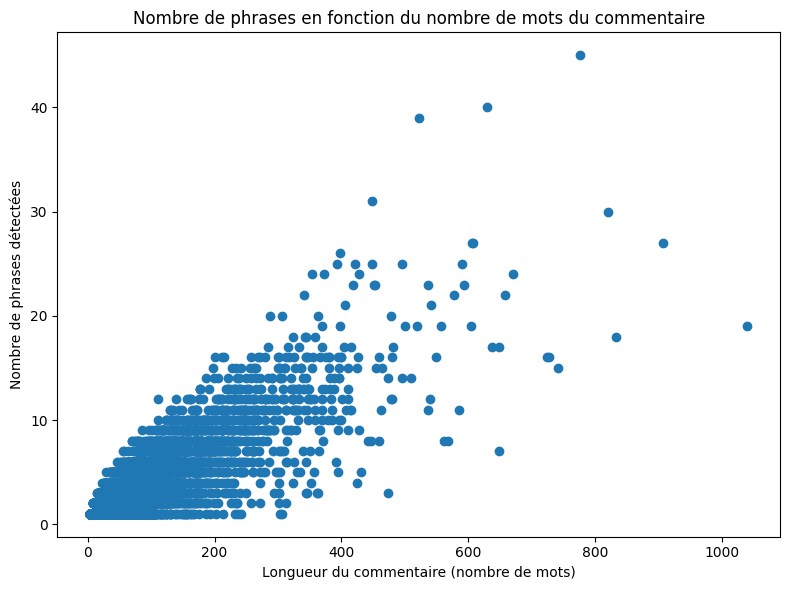

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

df["word_count"] = df["clean_comment"].apply(lambda x: len(x.split()))

sentence_counts = df_sentences.groupby("comment_id").size()

stats = df[["word_count"]].copy()
stats["n_sentences"] = sentence_counts

plt.figure(figsize=(8, 6))
plt.scatter(stats["word_count"], stats["n_sentences"])
plt.xlabel("Longueur du commentaire (nombre de mots)")
plt.ylabel("Nombre de phrases détectées")
plt.title("Nombre de phrases en fonction du nombre de mots du commentaire")
plt.tight_layout()
plt.show()

In [36]:
# Voir les commentaires avec beaucoup de phrases

sentence_counts = df_sentences.groupby("comment_id").size()
long_comments_ids = sentence_counts[sentence_counts > 40].index
df_long = df.loc[long_comments_ids]
df_long['Commentaire']

comment_id
1514    Je vais me joindre à l'avis de beaucoup . J'ai...
Name: Commentaire, dtype: object

## Sentence embeddings

In [25]:
from sentence_transformers import SentenceTransformer
!pip install bertopic
from bertopic import BERTopic

/mnt/c/Users/charb/Documents/ALTERNANCE/Datascientest/Projet/TrustPilot/DS/trustpilot/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


#### Sentence-BERT multilingue


In [26]:
# Vectorisation (modèle au choix, il faudra en tester plusieurs)
embedding_model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2") # modèle multilingue de type sentence-bert

# pour utiliser le GPU en locale
if torch.cuda.is_available():
    embedding_model = embedding_model.to('cuda')

sentences = df_sentences["sentence"].tolist()
sbert_embeddings = embedding_model.encode(sentences)
sbert_embeddings = normalize(sbert_embeddings, norm='l2')
sbert_embeddings.shape

(37628, 384)

In [27]:
with open("../data/embeddings/emb_sbert_multi_phrases.pkl", "wb") as f:
  pickle.dump(sbert_embeddings, f)

#### Sentence-BERT multilingue 2

In [28]:
# Vectorisation (modèle au choix, il faudra en tester plusieurs)
embedding_model = SentenceTransformer("all-mpnet-base-v2") # modèle multilingue de type sentence-bert

# pour utiliser le GPU en locale
if torch.cuda.is_available():
    embedding_model = embedding_model.to('cuda')

sentences = df_sentences["sentence"].tolist()
sbert_embeddings = embedding_model.encode(sentences)
sbert_embeddings = normalize(sbert_embeddings, norm='l2')
sbert_embeddings.shape

(37628, 768)

In [29]:
with open("../data/embeddings/emb_sbert_multi2_phrases.pkl", "wb") as f:
  pickle.dump(sbert_embeddings, f)

#### CamemBERT (BERT français)



In [30]:
# Vectorisation (modèle au choix, il faudra en tester plusieurs)
embedding_model = SentenceTransformer('camembert-base') # modèle français de type bert

# pour utiliser le GPU en locale
if torch.cuda.is_available():
    embedding_model = embedding_model.to('cuda')

sentences = df_sentences["sentence"].tolist()
sbert_embeddings = embedding_model.encode(sentences)
sbert_embeddings = normalize(sbert_embeddings, norm='l2')
sbert_embeddings.shape

No sentence-transformers model found with name camembert-base. Creating a new one with mean pooling.


(37628, 768)

In [31]:
with open("../data/embeddings/emb_sbert_fr_phrases.pkl", "wb") as f:
  pickle.dump(sbert_embeddings, f)

#### BERTopic (Topic modeling)


In [34]:
# # BERTopic

# # Création de BERTopic
# topic_model = BERTopic(embedding_model=embedding_model, language="french")
# topics, probs = topic_model.fit_transform(df["clean_comment"])

# # Visualisation des thèmes
# print(topic_model.get_topic_info())
# print(topic_model.get_topic(0))  # mots du thème 0

## Enregistrement final

In [35]:
with open("../data/processed/dataset_final_phrases.pkl", "wb") as f:
  pickle.dump(df_sentences, f)